# Aproximação de Função Não Linear com Sistema Fuzzy Takagi-Sugeno

Este notebook implementa um sistema fuzzy Takagi-Sugeno de ordem zero para aproximar a função:

$$
f(x) = e^{-x/5} \cdot \sin(3x) + 0.5 \cdot \sin(x)
$$

no intervalo $x \in [0, 10]$.

Serão detalhados: geração dos dados, estrutura fuzzy, funções de pertinência, operadores, ajuste dos consequentes, avaliação e análise dos resultados.

In [17]:
# 1. Geração dos dados
import numpy as np

# Gera 200 pontos uniformemente espaçados no intervalo [0, 10]
x = np.linspace(0, 10, 200)
def f(x):
    return np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)
y = f(x)

## Estrutura do Sistema Fuzzy Takagi-Sugeno

- **Variável de entrada:** $x \in [0, 10]$
- **Variável de saída:** $y \approx f(x)$
- **Número de regras:** 3 (Baixo, Médio, Alto)
- **Funções de pertinência:** Triangulares, cobrindo todo o intervalo de $x$
- **Consequentes:** Constantes (ordem zero)
- **Operador de agregação:** Soma ponderada pelas pertinências

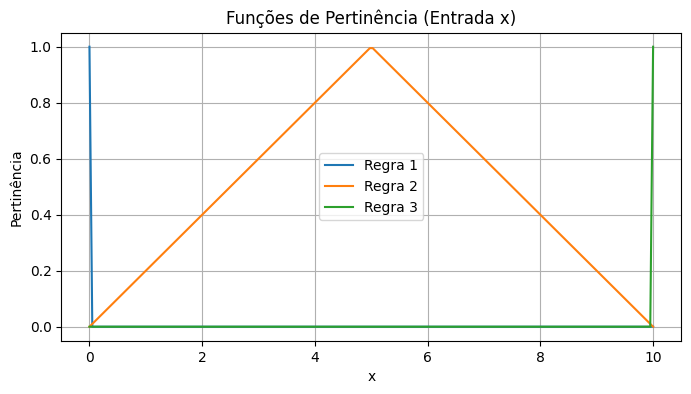

In [ ]:
# 2. Definição das funções de pertinência triangulares
def triangular(x, a, b, c):
    # Evita divisões por zero nos vértices
    left = np.zeros_like(x, dtype=float)
    right = np.zeros_like(x, dtype=float)
    if b != a:
        left = (x - a) / (b - a)
    else:
        left = np.where(x == a, 1.0, 0.0)
    if c != b:
        right = (c - x) / (c - b)
    else:
        right = np.where(x == c, 1.0, 0.0)
    return np.maximum(np.minimum(left, right), 0)

# Parâmetros das funções de pertinência
mf_params = [
    (0, 0, 5),   # Baixo
    (0, 5, 10),  # Médio
    (5, 10, 10)  # Alto
]

def compute_mfs(x):
    return np.array([triangular(x, *p) for p in mf_params])

# Visualização das funções de pertinência
import matplotlib.pyplot as plt
import os

def plot_mfs(x, mf_params, save_path=None):
    plt.figure(figsize=(8,4))
    for i, (a, b, c) in enumerate(mf_params):
        plt.plot(x, triangular(x, a, b, c), label=f'Regra {i+1}')
    plt.title('Funções de Pertinência (Entrada x)')
    plt.xlabel('x')
    plt.ylabel('Pertinência')
    plt.legend()
    plt.grid(True)
    if save_path:
        # Cria a pasta se não existir, mas não apaga se já existir
        img_dir = os.path.dirname(save_path)
        if img_dir and not os.path.exists(img_dir):
            os.makedirs(img_dir)
        plt.savefig(save_path)
    plt.show()

# Cria pasta img se não existir
if not os.path.exists('img'):
    os.makedirs('img')
plot_mfs(np.linspace(0,10,200), mf_params, save_path='img/mfs.png')

## Regras Fuzzy

- **Regra 1:** Se $x$ é **Baixo** então $y = c_1$
- **Regra 2:** Se $x$ é **Médio** então $y = c_2$
- **Regra 3:** Se $x$ é **Alto** então $y = c_3$

Os consequentes $c_i$ serão ajustados para minimizar o erro quadrático médio (MSE).

In [19]:
# 3. Ajuste dos consequentes (ordem zero) via mínimos quadrados

# Calcula pertinências para todos os x
mfs = compute_mfs(x)  # shape: (3, N)

# Para cada regra, calcula o consequente ótimo (média ponderada dos y pelos graus de pertinência)
c = []
for i in range(3):
    w = mfs[i]
    # Evita divisão por zero
    if np.sum(w) > 0:
        c_i = np.sum(w * y) / np.sum(w)
    else:
        c_i = 0
    c.append(c_i)
c = np.array(c)
print("Consequentes ótimos (ordem zero):", c)

Consequentes ótimos (ordem zero): [ 0.         -0.02385904 -0.4057261 ]


In [20]:
# 4. Inferência Takagi-Sugeno (ordem zero)
def ts_zero(x, mf_params, c):
    mfs = np.array([triangular(x, *p) for p in mf_params])
    num = np.sum(mfs * c[:,None], axis=0)
    den = np.sum(mfs, axis=0)
    # Evita divisão por zero
    y_hat = np.where(den > 0, num/den, 0)
    return y_hat

y_hat = ts_zero(x, mf_params, c)

In [21]:
# 5. Avaliação do desempenho
# Cálculo manual do MSE e RMSE
mse = np.mean((y - y_hat) ** 2)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.6f} | RMSE: {rmse:.6f}")

MSE: 0.249848 | RMSE: 0.499848


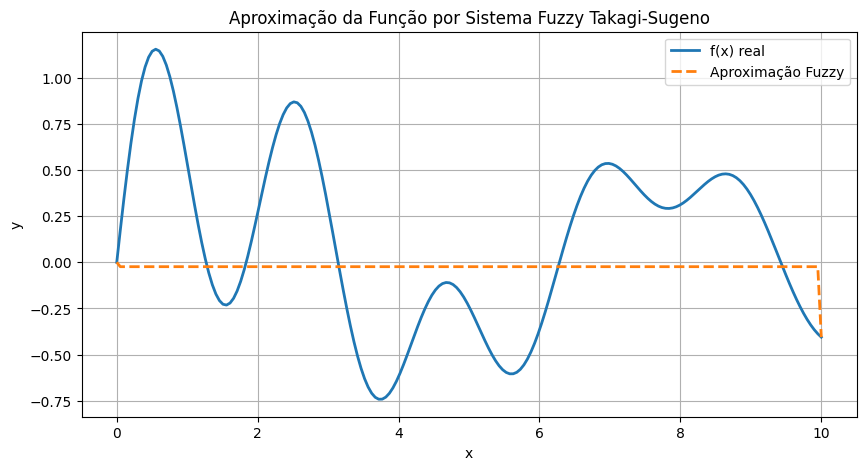

In [ ]:
# 6. Plot dos resultados
def plot_results(x, y, y_hat, save_path=None):
    plt.figure(figsize=(10,5))
    plt.plot(x, y, label='f(x) real', linewidth=2)
    plt.plot(x, y_hat, '--', label='Aproximação Fuzzy', linewidth=2)
    plt.title('Aproximação da Função por Sistema Fuzzy Takagi-Sugeno')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    if save_path:
        img_dir = os.path.dirname(save_path)
        if img_dir and not os.path.exists(img_dir):
            os.makedirs(img_dir)
        plt.savefig(save_path)
    plt.show()

plot_results(x, y, y_hat, save_path='img/approx.png')

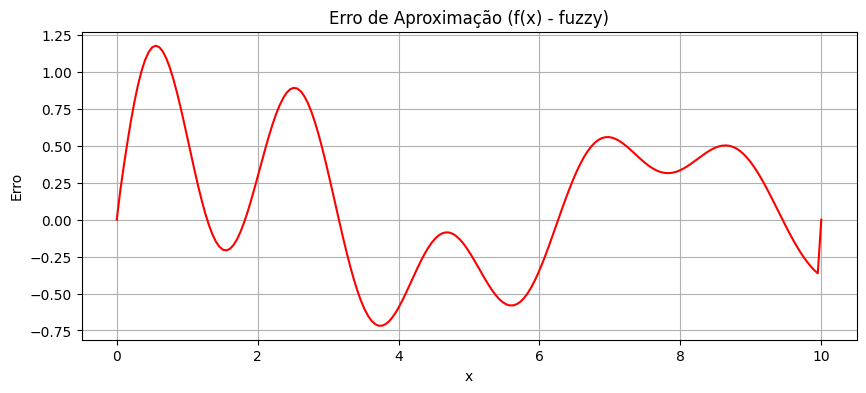

In [ ]:
# 7. Plot do erro
def plot_error(x, y, y_hat, save_path=None):
    plt.figure(figsize=(10,4))
    plt.plot(x, y - y_hat, color='red')
    plt.title('Erro de Aproximação (f(x) - fuzzy)')
    plt.xlabel('x')
    plt.ylabel('Erro')
    plt.grid(True)
    if save_path:
        img_dir = os.path.dirname(save_path)
        if img_dir and not os.path.exists(img_dir):
            os.makedirs(img_dir)
        plt.savefig(save_path)
    plt.show()

plot_error(x, y, y_hat, save_path='img/error.png')

## Análise dos Resultados

- **MSE/RMSE** apresentados acima.
- O sistema fuzzy de ordem zero com 3 regras já aproxima razoavelmente a função alvo, mas pode ser melhorado.
- Testes com mais regras, funções de pertinência diferentes (gaussianas, trapezoidais) e consequentes de primeira ordem podem reduzir ainda mais o erro.
- O erro é maior nas regiões onde a função muda rapidamente, sugerindo que mais regras ou consequentes lineares podem ser úteis.

### Próximos Passos

- Testar consequentes de primeira ordem (Takagi-Sugeno de 1ª ordem).
- Experimentar diferentes funções de pertinência e operadores.
- Comparar os resultados e analisar o impacto das variações.